# Face Recognition ArcFace v2

## 1.0 Setup

**1.1 Installing & Importing Required Packages**

In [1]:
# utilities
import sys
import os
import shutil
import random
import json
import time
import multiprocessing
from collections import defaultdict
import io
from pprint import pprint
from tqdm.auto import tqdm

# torch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, ConcatDataset, Subset
import torchvision.transforms as T
import torchvision
import torch.nn.functional as F
# from retinaface.pre_trained_models import get_model
from torchvision.datasets import ImageFolder
import torchvision.models as tv_models


# images/arrays
import numpy as np
import pandas as pd
import cv2
import PIL
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from PIL.Image import fromarray
from PIL import Image, ImageFilter

# custom
from src.utils.functional import load_image_cv, bgr_loader, denormalize_img_tensor, tensor_to_ndarry, load_obj
from src.models.training import train_arc_face_model, get_loaders, load_checkpoint, plot_train_results
from src.models.models import IResNet, IBasicBlock, ArcFaceHead
from src.data.datasets import ArcFaceV2PairsDataset, ArcFaceDatasetV2
from src.models.evaluation import calc_thresholds

**1.2 Configurations**

In [ ]:
IMAGE_SIZE = 112
MEANs = [0.5, 0.5, 0.5]
STDs = [0.5, 0.5, 0.5]

---
---

## 2.0 Data Preparation

**2.1 Load Data**

In [10]:
DATA_PATH = "/kaggle/input/datasets/ragabahmed/face-recognition-detected"

full_data = ImageFolder(root = DATA_PATH, loader = bgr_loader)
type(full_data)

torchvision.datasets.folder.ImageFolder

In [11]:
label_to_idx = full_data.class_to_idx
idx_to_label = {val : key for key, val in label_to_idx.items()}

**2.2 Split Data**

In [12]:
def stratified_split(dataset, val_ratio = 0.15, seed = 42, min_val_per_class = 1):
    """
    Splitting the dataset such that each person is guaranteed to be presented in the validation dataset
    """
    random.seed(seed)
    class_to_indices = defaultdict(list)

    for idx, (_, label) in enumerate(dataset.samples):
        class_to_indices[label].append(idx)


    train_indices = []
    val_indices = []
    for label, indices in class_to_indices.items():
        random.shuffle(indices)

        n = len(indices)

        # guarantee at least 1 val image if class has >= 2 images
        if n >= 2:
            n_val = max(min_val_per_class, int(n * val_ratio))
            n_val = min(n_val, n - 1) 
        else:
            n_val = 0  

        val_indices.extend(indices[:n_val])
        train_indices.extend(indices[n_val:])

    train_dataset = Subset(dataset, train_indices)
    val_dataset = Subset(dataset, val_indices)

    return train_dataset, val_dataset

In [13]:
VAL_RATIO = 0.15
RANDOM_SEED = 42

train_dataset, val_dataset = stratified_split(
    dataset = full_data,
    val_ratio = VAL_RATIO,
    seed = RANDOM_SEED,
    min_val_per_class = 1
)

print("Train Dataset")
print(f"--- Type: {type(train_dataset)}")
print(f"--- Len : {len(train_dataset)}")
print()
print("Val Dataset")
print(f"--- Type: {type(val_dataset)}")
print(f"--- Len : {len(val_dataset)}")

Train Dataset
--- Type: <class 'torch.utils.data.dataset.Subset'>
--- Len : 67309

Val Dataset
--- Type: <class 'torch.utils.data.dataset.Subset'>
--- Len : 11508


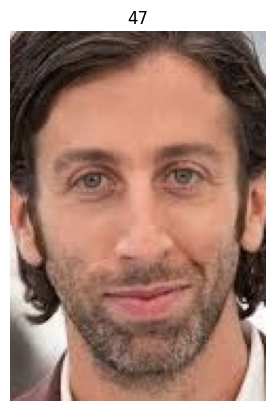

In [14]:
# test a sample
index = 523
sample = train_dataset[index]

img = np.array(sample[0])
lab = idx_to_label[sample[1]]

show_images(images = [img], titles = [lab])

**2.2 Building Custom Dataset**

In [17]:
# transformations
class JPEGCompression:
    """Simulates Old ID Cards"""
    def __init__(self, quality_range = (35, 85), p = 0.35):
        self.quality_range = quality_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        buffer = io.BytesIO()
        quality = random.randint(*self.quality_range)

        img.save(buffer, format ="JPEG", quality = quality)
        buffer.seek(0)

        return Image.open(buffer).convert("RGB")


class RandomSlightBlur:
    """Simulates Blurry Card"""
    def __init__(self, radius_range = (0.3, 1.2), p = 0.25):
        self.radius_range = radius_range
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            radius = random.uniform(*self.radius_range)
            return img.filter(ImageFilter.GaussianBlur(radius))

        return img

class GaussianNoise:
    def __init__(self, std = 0.025, p = 0.25):
        self.std = std
        self.p = p

    def __call__(self, x):
        if random.random() < self.p:
            x = x + torch.randn_like(x) * self.std
            x = torch.clamp(x, 0.0, 1.0)

        return x


train_transform = T.Compose([
    # resizing
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),


    # augmentations
    T.RandomHorizontalFlip(p = 0.5),
    T.RandomApply([T.RandomRotation(degrees = 4)], p = 0.25),
    JPEGCompression(quality_range = (35, 85), p = 0.35),
    RandomSlightBlur(radius_range = (0.3, 1.2), p = 0.25),
    T.ColorJitter(
        brightness = 0.20,
        contrast = 0.25,
        saturation = 0.12,
        hue = 0.02
    ),

    T.RandomGrayscale(p = 0.10),

    # PIL to Tensor
    T.ToTensor(),
    GaussianNoise(std = 0.025, p = 0.25),

    # normalization
    T.Normalize(
        mean = MEANs,
        std = STDs
    )
])


val_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(
        mean = MEANs,
        std = STDs
    )
])

In [50]:
prepared_trained_dataset = ArcFaceDatasetV2(
    dataset = train_dataset,
    transformer = train_transform,
)

prepared_val_dataset = ArcFaceDatasetV2(
    dataset = val_dataset,
    transformer = val_transform
)

print("Train Dataset")
print("--- Length:", len(prepared_trained_dataset))
print("--- Type  :", type(prepared_trained_dataset))
print()
print("val Dataset")
print("--- Length:", len(prepared_val_dataset))
print("--- Type  :", type(prepared_val_dataset))

Train Dataset
--- Length: 67309
--- Type  : <class '__main__.ArcFaceDatasetV2'>

val Dataset
--- Length: 11508
--- Type  : <class '__main__.ArcFaceDatasetV2'>


In [51]:
# test samples
sample = prepared_trained_dataset[75]

print(f"Type: {type(sample)}")


img = sample[0]
print("IMG")
print(f"--- Type : {type(img)}")
print(f"--- Shape: {img.shape}")

lab = sample[1]
print("Label")
print(f"--- Type : {type(lab)}")
print(f"--- Shape: {lab.shape}")
print(f"--- value: {lab.item()}")

Type: <class 'tuple'>
IMG
--- Type : <class 'torch.Tensor'>
--- Shape: torch.Size([3, 112, 112])
Label
--- Type : <class 'torch.Tensor'>
--- Shape: torch.Size([])
--- value: 6


**2.3 Data Loaders**

In [52]:
workers = 4

# data loaders
train_data_loader, val_data_loader, _ = get_loaders(
    train_dataset = prepared_trained_dataset,
    val_dataset = prepared_val_dataset,
    test_dataset = None,
    batch_size = 64,
    num_workers = workers
)

# test
print(f"Train data loader: {type(train_data_loader)}")
print(f"Number of batches in an epoch: {len(train_data_loader)}")
print(f"Number of images in an epoch: {len(train_data_loader.dataset)}")
print(f"Batch size: {train_data_loader.batch_size}")

print(100 * '-')

print(f"Val data loader: {type(val_data_loader)}")
print(f"Number of batches in an epoch: {len(val_data_loader)}")
print(f"Number of images in an epoch: {len(val_data_loader.dataset)}")
print(f"Batch size: {val_data_loader.batch_size}")

Train data loader: <class 'torch.utils.data.dataloader.DataLoader'>
Number of batches in an epoch: 1052
Number of images in an epoch: 67309
Batch size: 64
----------------------------------------------------------------------------------------------------
Val data loader: <class 'torch.utils.data.dataloader.DataLoader'>
Number of batches in an epoch: 180
Number of images in an epoch: 11508
Batch size: 64


In [53]:
# visualize examples
train_iter = iter(train_data_loader)
val_iter = iter(val_data_loader)

In [54]:
train_batch, val_batch = next(train_iter), next(val_iter)

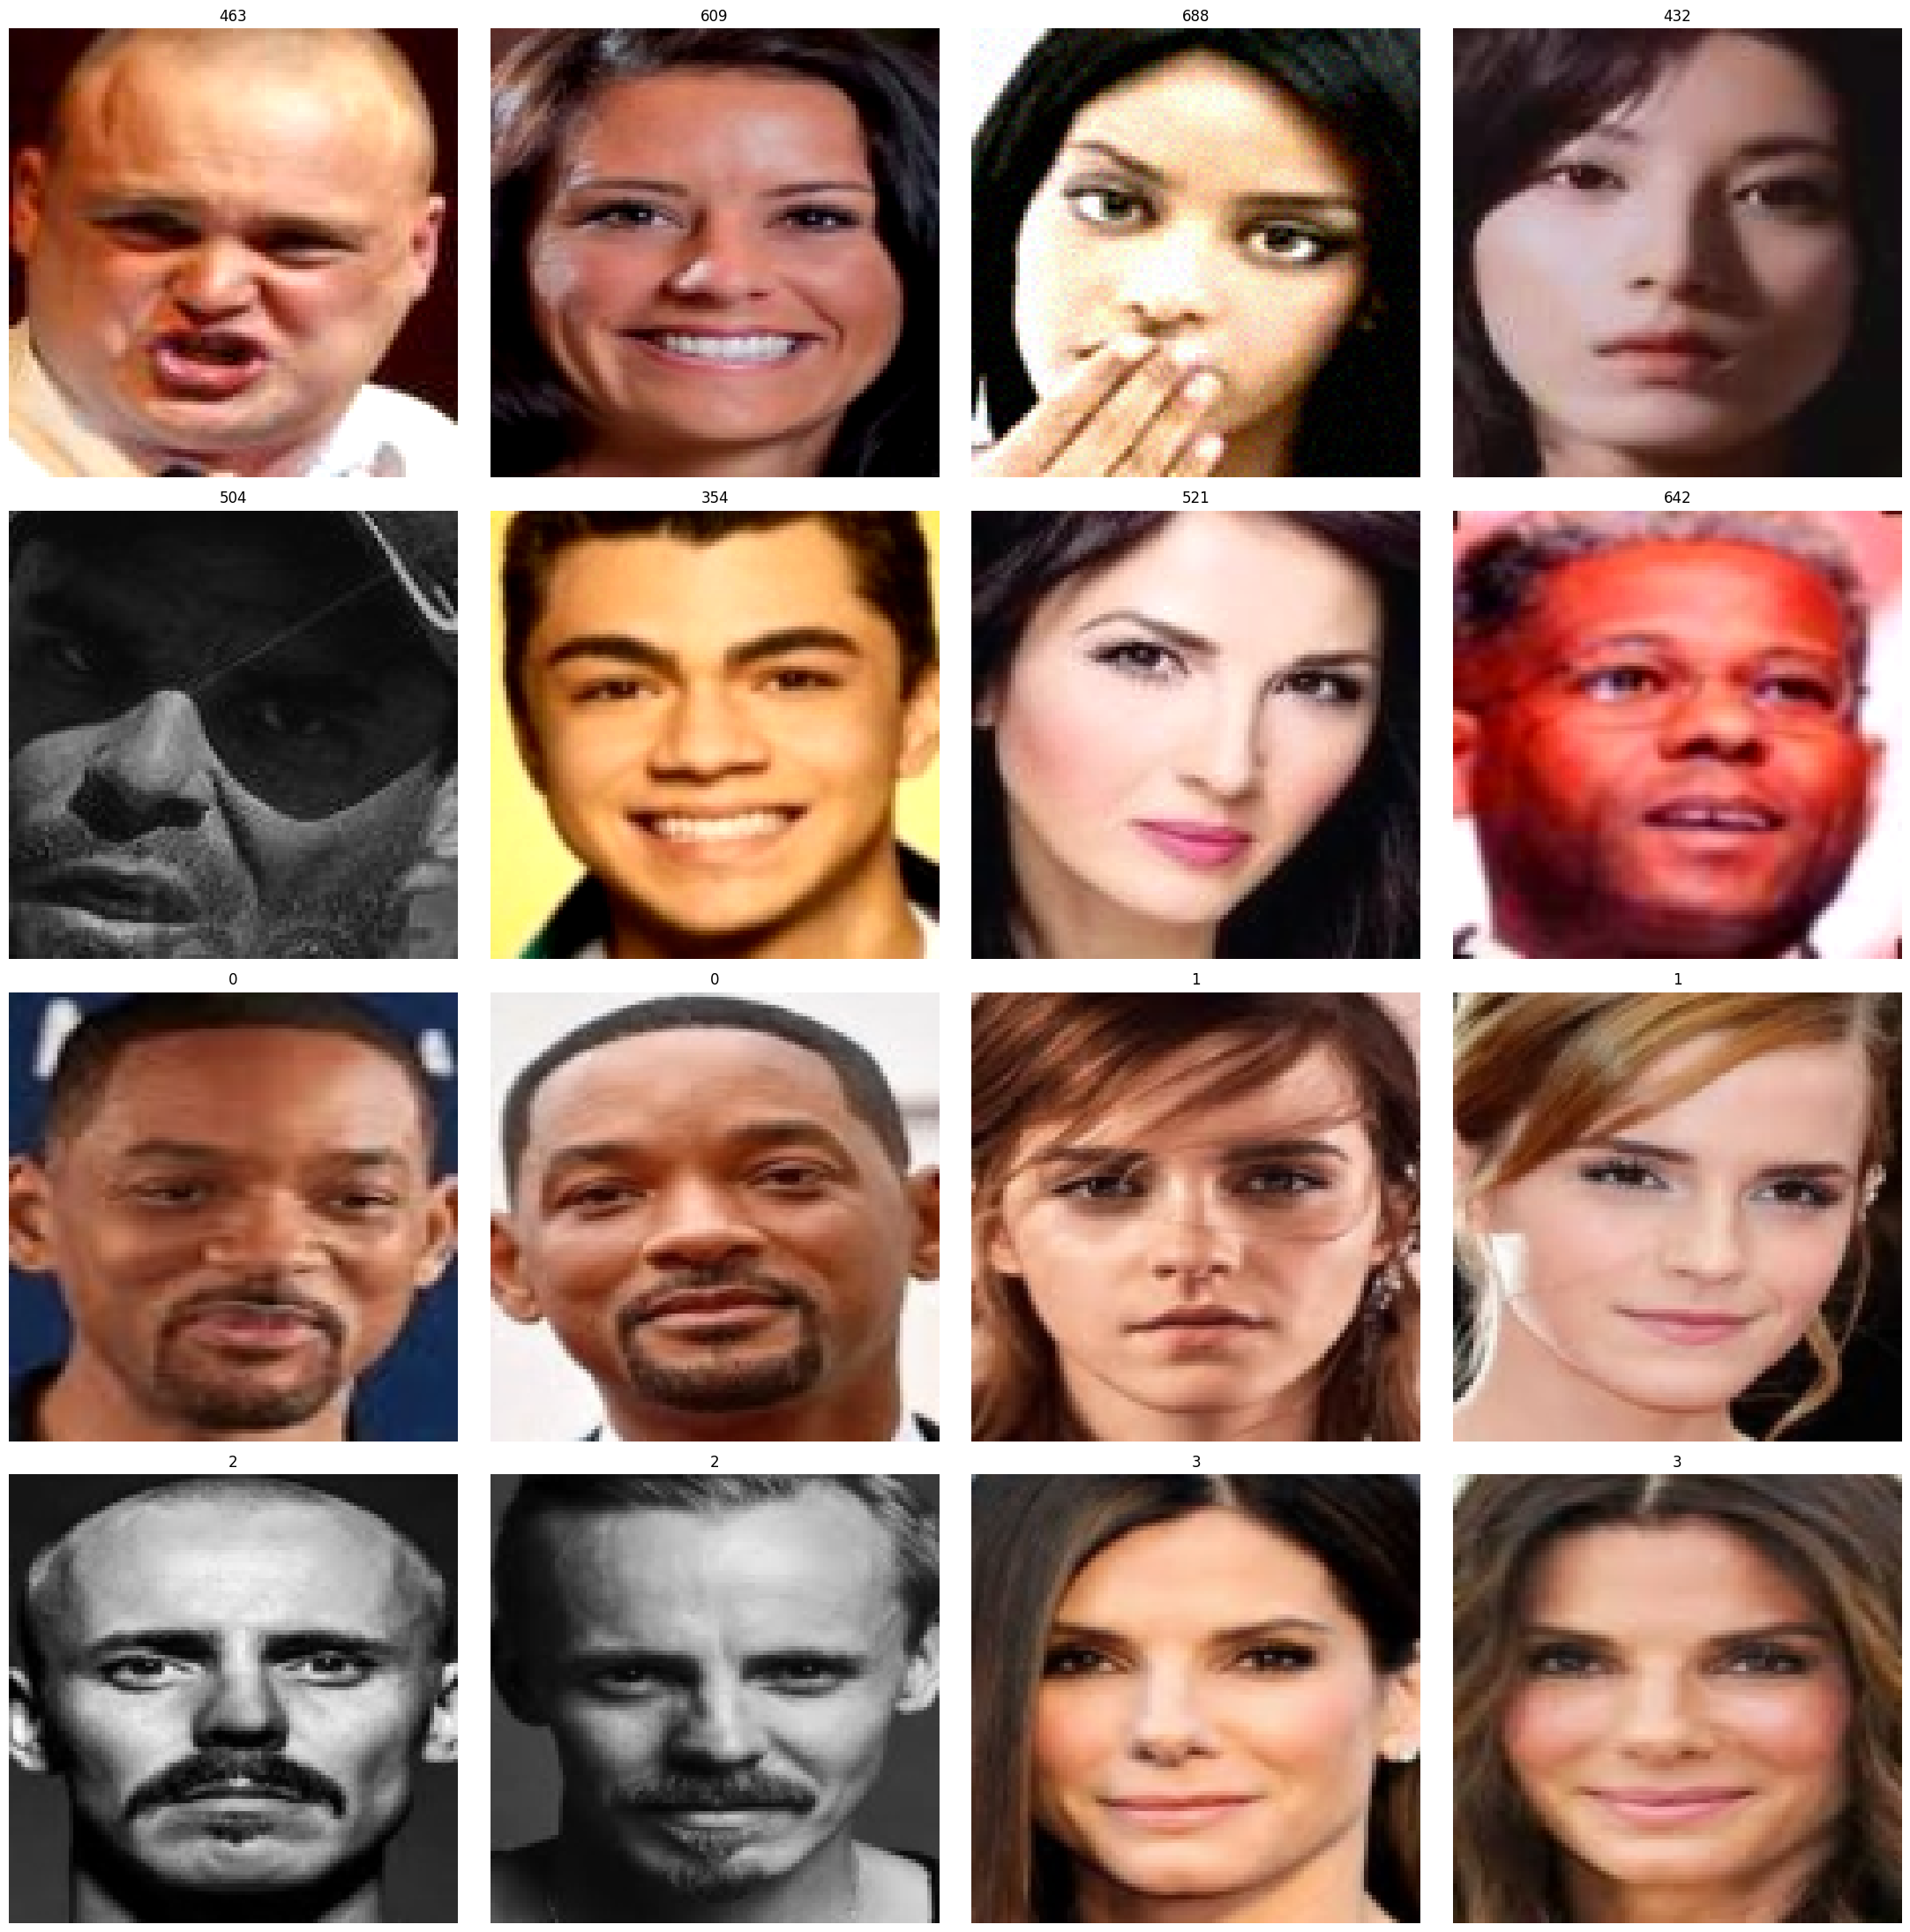

In [57]:
images = torch.cat((train_batch[0][:8], val_batch[0][:8]))
labels = torch.cat((train_batch[1][:8], val_batch[1][:8]))
_, axes = plt.subplots(nrows = 4, ncols = 4, figsize = (22, 22))

for img, lab, ax in zip(images, labels, axes.flat):
    img = tensor_to_ndarry(denormalize_img_tensor(img, means = MEANs, stds = STDs))
    lab = lab.item()
    ax.imshow(img)
    ax.set_title(lab)
    ax.axis("off")

plt.tight_layout()
plt.show()

- Some noisy not-aligned images exist.

---
---

## 3.0 Modeling

**Train the Head**

In [58]:
n_persons = len(label_to_idx)
n_persons

786

In [61]:
arcface_margin_5 = FaceRecognizerArcFace(
    num_classes = n_persons,
    backbone_weights = True,
    backbone_weights_link = "/kaggle/input/models/mxrouane/iresnet-34-50-100-weights/pytorch/default/1/iresnet50-7f187506.pth"
)

for param in arcface_margin_5.parameters():
    param.requires_grad = False

arcface_margin_5
for param in arcface_margin_5.arc_face.parameters():
    param.requires_grad = True

for name, param in arcface_margin_5.named_parameters():
    if param.requires_grad:
        print(name, param.shape)
print(100 * '-')

arc_face.weight torch.Size([786, 512])
----------------------------------------------------------------------------------------------------


In [62]:
optimizer = torch.optim.Adam(
    params = filter(lambda p : p.requires_grad, arcface_margin_5.parameters()), 
    lr = 1e-3,
    weight_decay = 3e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer = optimizer,
    mode = 'max',
    factor = 0.5,     
    patience = 3,
    threshold = 1e-3,
)


# loss
criterion = nn.CrossEntropyLoss()

In [63]:
results = train_arc_face_model(
    model = arcface_margin_5,
    train_data_loader = train_data_loader,
    val_data_loader = val_data_loader,
    loss_fn = criterion,
    optimizer = optimizer,
    scheduler = scheduler,
    epochs = 5,
    trained_epochs = 0,
    train_losses = [],
    val_losses = [],
    train_accs = [],
    val_accs = [],
    best_val_acc = 0,
    patience = 12, # do not activate
)

>> Epoch: 1
• LR_0: 0.001
• WD: 3e-05


Validation: 100%|██████████| 180/180 [00:36<00:00,  4.90it/s, acc=0.6784, loss=2.1724]


>> Epoch: 2
• LR_0: 0.001
• WD: 3e-05


Validation: 100%|██████████| 180/180 [00:36<00:00,  4.90it/s, acc=0.6910, loss=2.1806]


>> Epoch: 3
• LR_0: 0.001
• WD: 3e-05


Validation: 100%|██████████| 180/180 [00:36<00:00,  4.90it/s, acc=0.6962, loss=2.1827]


>> Epoch: 4
• LR_0: 0.001
• WD: 3e-05


Validation: 100%|██████████| 180/180 [00:36<00:00,  4.93it/s, acc=0.6968, loss=2.1909]


>> Epoch: 5
• LR_0: 0.001
• WD: 3e-05


Validation: 100%|██████████| 180/180 [00:36<00:00,  4.90it/s, acc=0.7000, loss=2.1863]


**Fine-Tune the Backbone**

In [64]:
for param in arcface_margin_5.parameters():
    param.requires_grad = True


for name, param in arcface_margin_5.named_parameters():
    if param.requires_grad:
        print(name, param.shape)
print(100 * '=')


optimizer = torch.optim.Adam(
    params = filter(lambda p : p.requires_grad, arcface_margin_5.parameters()), 
    lr = 1e-5,
    weight_decay = 3e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer = optimizer,
    mode = 'max',
    factor = 0.5,     
    patience = 3,
    threshold = 1e-3,
)


# loss
criterion = nn.CrossEntropyLoss()

backbone.conv1.weight torch.Size([64, 3, 3, 3])
backbone.bn1.weight torch.Size([64])
backbone.bn1.bias torch.Size([64])
backbone.prelu.weight torch.Size([64])
backbone.layer1.0.bn1.weight torch.Size([64])
backbone.layer1.0.bn1.bias torch.Size([64])
backbone.layer1.0.conv1.weight torch.Size([64, 64, 3, 3])
backbone.layer1.0.bn2.weight torch.Size([64])
backbone.layer1.0.bn2.bias torch.Size([64])
backbone.layer1.0.prelu.weight torch.Size([64])
backbone.layer1.0.conv2.weight torch.Size([64, 64, 3, 3])
backbone.layer1.0.bn3.weight torch.Size([64])
backbone.layer1.0.bn3.bias torch.Size([64])
backbone.layer1.0.downsample.0.weight torch.Size([64, 64, 1, 1])
backbone.layer1.0.downsample.1.weight torch.Size([64])
backbone.layer1.0.downsample.1.bias torch.Size([64])
backbone.layer1.1.bn1.weight torch.Size([64])
backbone.layer1.1.bn1.bias torch.Size([64])
backbone.layer1.1.conv1.weight torch.Size([64, 64, 3, 3])
backbone.layer1.1.bn2.weight torch.Size([64])
backbone.layer1.1.bn2.bias torch.Size([6

In [65]:
pprint(results)

{'best_val_acc': 0.700034758428919,
 'train_accs': [0.003387362759809238,
                0.012271761577203643,
                0.014277436895511744,
                0.015540269503335364,
                0.01485685420968964],
 'train_losses': [30.006974344747032,
                  26.242582953653308,
                  25.664600083501703,
                  25.45765594559839,
                  25.356274290211932],
 'trained_epochs': 5,
 'val_accs': [0.6783976364268335,
              0.6909975669099757,
              0.6962113312478276,
              0.6968196037539103,
              0.700034758428919],
 'val_losses': [2.172389186999016,
                2.180571842657679,
                2.1827030518339208,
                2.190893561549182,
                2.1863085145456407]}


In [66]:
trained_epochs = results['trained_epochs']
train_losses = results['train_losses']
val_losses = results['val_losses']
train_accs = results['train_accs']
val_accs = results['val_accs']
best_val_acc = results['best_val_acc']

In [67]:
TRAINED_MODELS_SAVE_PATH = "/kaggle/working/arcface_best_model"
os.makedirs(TRAINED_MODELS_SAVE_PATH, exist_ok = True)

In [69]:
results = train_arc_face_model(
    model = arcface_margin_5,
    train_data_loader = train_data_loader,
    val_data_loader = val_data_loader,
    loss_fn = criterion,
    optimizer = optimizer,
    scheduler = scheduler,
    epochs = 50,
    trained_epochs = trained_epochs,
    train_losses = train_losses,
    val_losses = val_losses,
    train_accs = train_accs,
    val_accs = val_accs,
    best_val_acc = best_val_acc,
    patience = 20,
    save_path = TRAINED_MODELS_SAVE_PATH
)

>> Epoch: 6
• LR_0: 1e-05
• WD: 3e-05


Validation: 100%|██████████| 180/180 [00:36<00:00,  4.89it/s, acc=0.9189, loss=0.5749]


>> Epoch: 7
• LR_0: 1e-05
• WD: 3e-05


Validation: 100%|██████████| 180/180 [00:36<00:00,  4.88it/s, acc=0.9446, loss=0.3932]


>> Epoch: 8
• LR_0: 1e-05
• WD: 3e-05


...

>> Epoch: 31
• LR_0: 2.5e-06
• WD: 3e-05


Validation: 100%|██████████| 180/180 [00:36<00:00,  4.88it/s, acc=0.9829, loss=0.1358]


>> Epoch: 32
• LR_0: 2.5e-06
• WD: 3e-05


Training:  56%|█████▌    | 587/1052 [06:43<05:19,  1.45it/s, acc=0.9772, loss=0.1060]


KeyboardInterrupt: 

**Training Results**

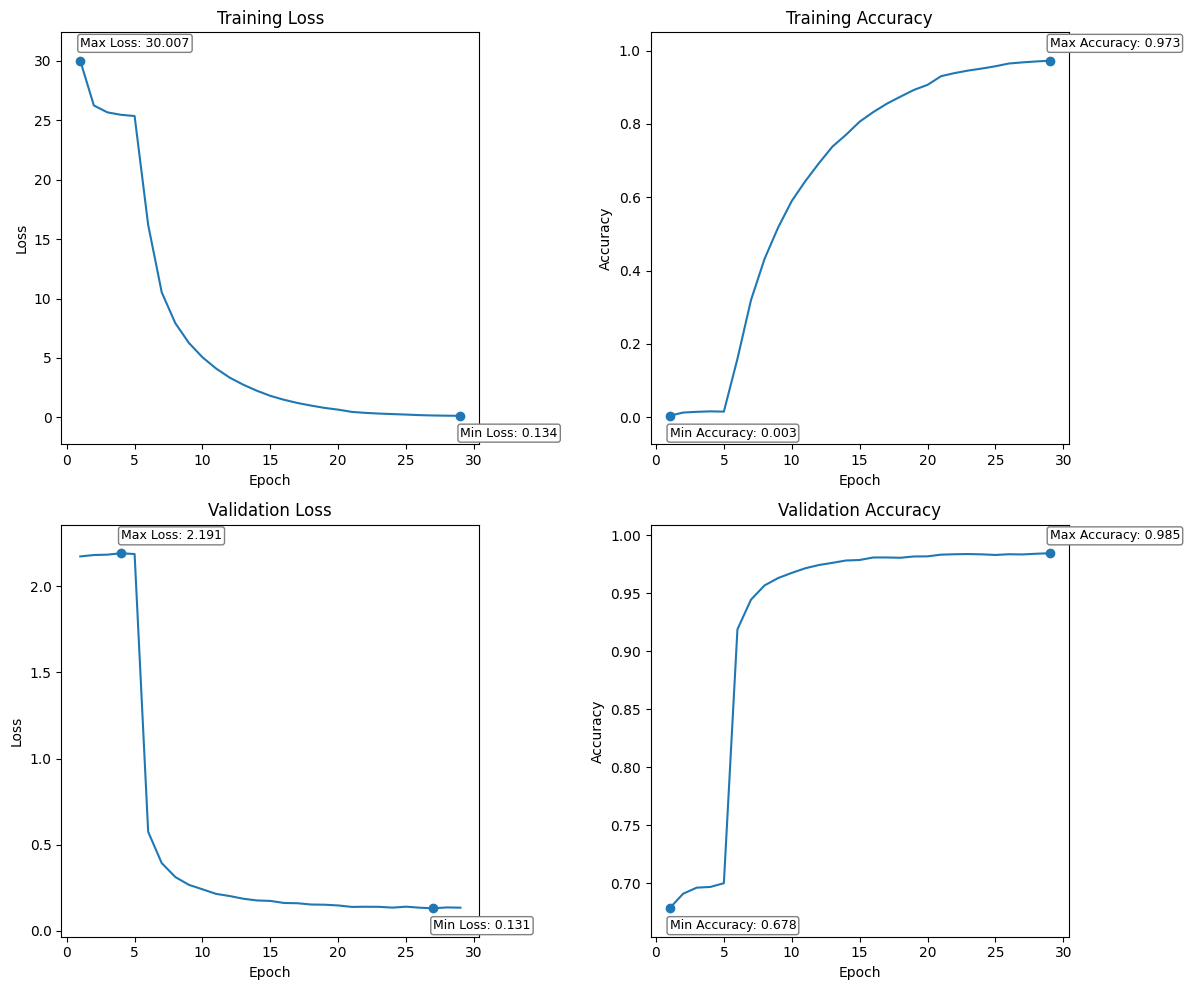

In [74]:
# load best results
best_results = load_obj(path = "/kaggle/working/arcface_best_model/arcface5_29_epochs_results.json")

# visualize
epochs = best_results["trained_epochs"]
training_losses = best_results["train_losses"]
training_accs = best_results["train_accs"]
val_losses = best_results["val_losses"]
val_accs = best_results["val_accs"]

plot_train_results(
    epochs = best_results["trained_epochs"],
    results = [training_losses, training_accs, val_losses, val_accs],
    titles = ["Training Loss", "Training Accuracy", "Validation Loss", "Validation Accuracy"],
    y_labels = ["Loss", "Accuracy", "Loss", "Accuracy"]
)

---
---

## 4.0 Evaluation
In this phase, we will evalute the model in the verification problem (same vs different) and extract the best possible thresholds best on metrics on validation subset.

**4.1 Shuffling the Validation dataset**

In [99]:
indices = torch.randperm(len(prepared_val_dataset))
shuffled_val_dataset = torch.utils.data.Subset(prepared_val_dataset, indices)

print(f">> First Person : {shuffled_val_dataset[0][1]}")
print(f">> Second Person: {shuffled_val_dataset[1][1]}") 
print(f">> Total Persons: {len(shuffled_val_dataset)}")

>> First Person : 611
>> Second Person: 735
>> Total Persons: 11508


**4.2 Constructing Pairs Dataset**

Different


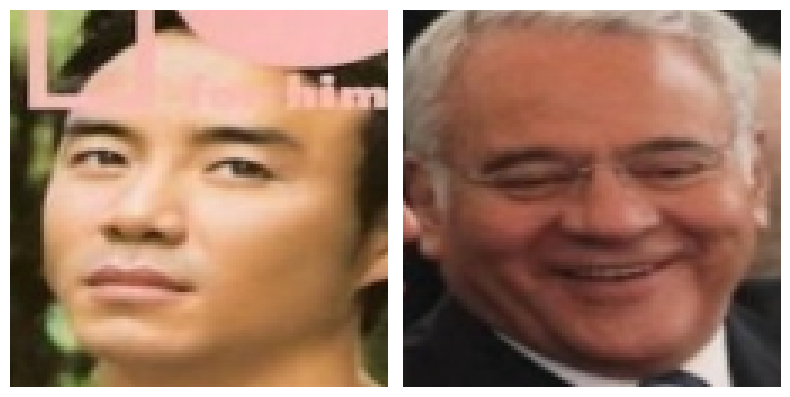

In [137]:
# test
pairs_dataset = ArcFaceV2PairsDataset(dataset = shuffled_val_dataset, transform = val_transform)

idx = 0
pair = pairs_dataset[idx]
(img1, img2), lab = pair

_, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 8))
is_same = "Same" if lab else "Different"

print(f"{is_same}")
ax1.imshow(tensor_to_ndarry(denormalize_img_tensor(img1, means = MEANs, stds = STDs))); 
ax2.imshow(tensor_to_ndarry(denormalize_img_tensor(img2, means = MEANs, stds = STDs)))

ax1.axis("off"); ax2.axis("off")

plt.tight_layout()
plt.show()

In [138]:
# data loader
evaluation_data_loader, _, _ = get_loaders(
    train_dataset = pairs_dataset,
    val_dataset = None,
    batch_size = 64,
    num_workers = 0
)
print(f"Eval data loader: {type(evaluation_data_loader)}")
print(f"Number of batches: {len(evaluation_data_loader)}")
print(f"Number of images in an epoch: {len(evaluation_data_loader.dataset)}")
print(f"Batch size: {evaluation_data_loader.batch_size}")

Eval data loader: <class 'torch.utils.data.dataloader.DataLoader'>
Number of batches: 313
Number of images in an epoch: 20000
Batch size: 64


In [139]:
it = iter(evaluation_data_loader)
batch = next(it)

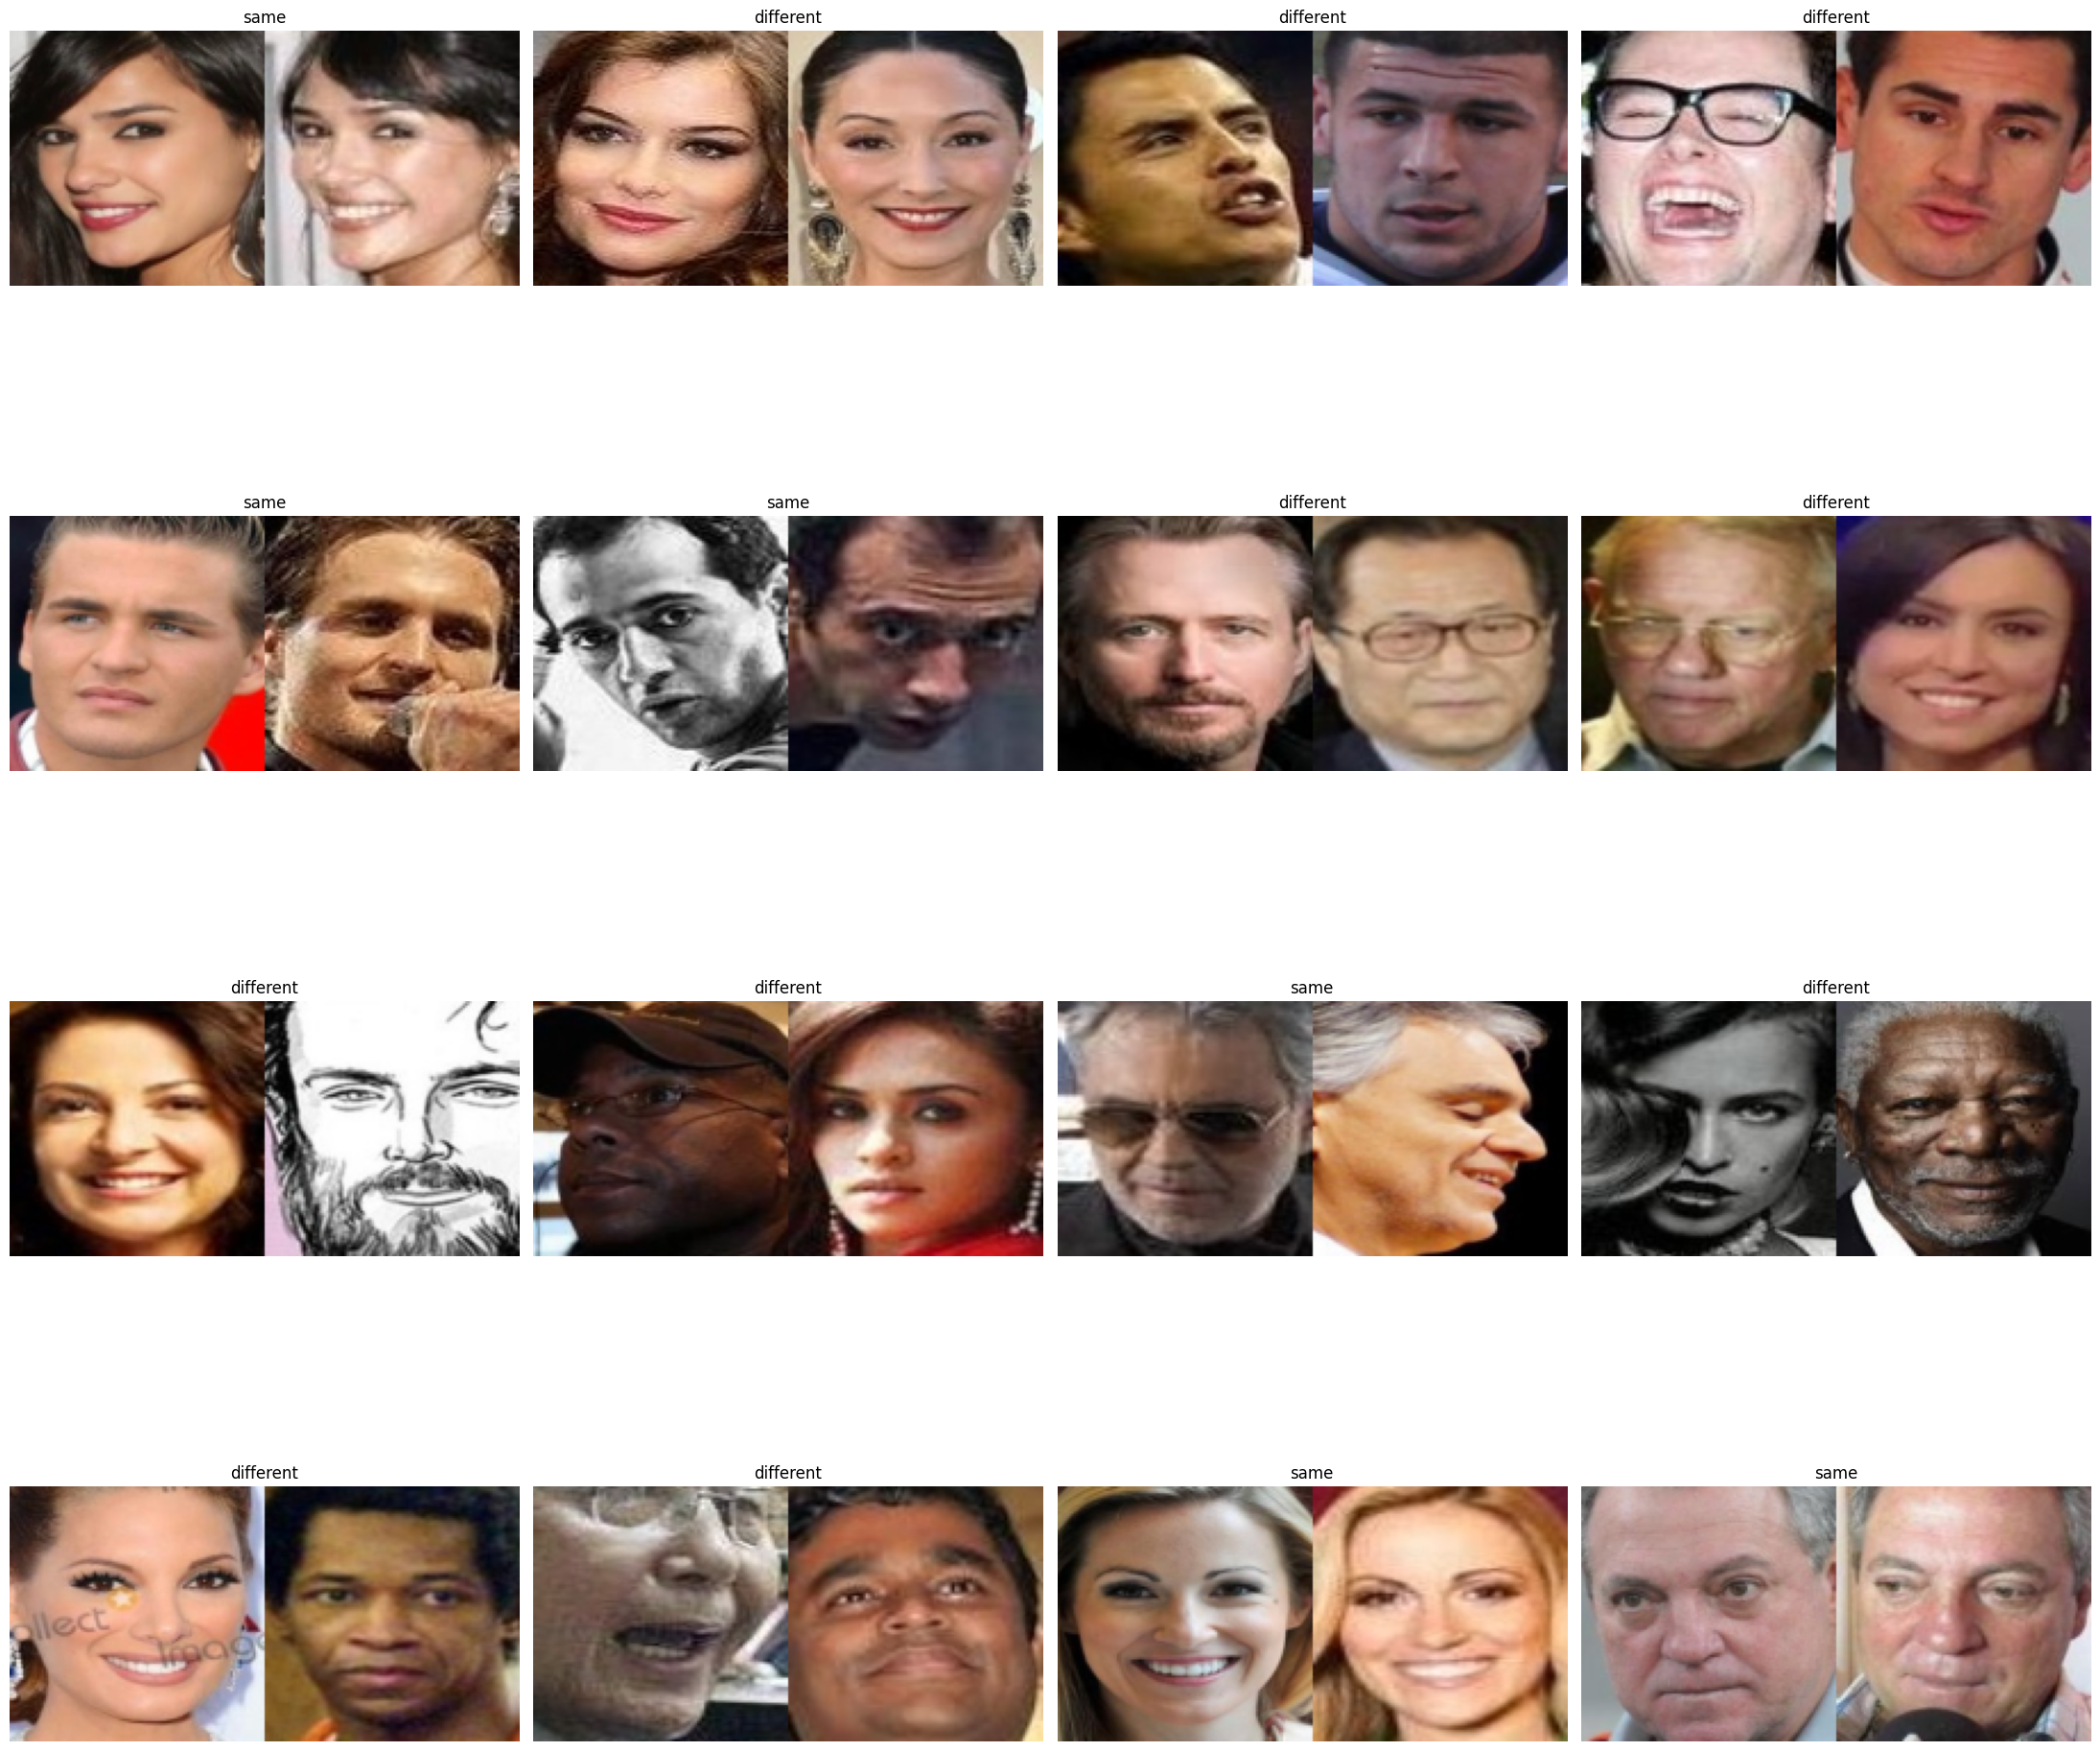

In [140]:
batch = next(it)
images = batch[0]
labels = batch[1]

_, axes = plt.subplots(nrows = 4, ncols = 4, figsize = (22, 22))

for img1, img2, lab, ax in zip(images[0], images[1], labels, axes.flat):
    img1 = tensor_to_ndarry(denormalize_img_tensor(img1, means = MEANs, stds = STDs))
    img2 = tensor_to_ndarry(denormalize_img_tensor(img2, means = MEANs, stds = STDs))
    img = np.concatenate((img1, img2), axis = 1)
    
    lab = 'same' if lab.item() else 'different'
    
    ax.imshow(img)
    ax.set_title(lab)
    ax.axis("off")

plt.tight_layout()
plt.show()

**4.4 Evaluaion**

In [141]:
# load best model
best_model, _, _ = load_checkpoint(
    path = "/kaggle/working/arcface_best_model/arc_face_best_model.pth",
    model = arcface_margin_5,
    device = config.DEVICE,
)

best_model.eval()

best_results = load_obj("/kaggle/working/arcface_best_model/arcface5_29_epochs_results.json")
best_results.keys()

dict_keys(['trained_epochs', 'train_losses', 'val_losses', 'train_accs', 'val_accs', 'best_val_acc'])

In [144]:
# calc thresholds
start_time = time.time()
best_model_evaluation_results = calc_thresholds(best_model, evaluation_data_loader)
finish_time = time.time() - start_time


print(f"{config.BULLET} Time Taken: {finish_time / 60:.2f} minutes")
print()

print(f'{config.BULLET} EER Results')
print(f'> Threshold : {best_model_evaluation_results["eer_threshold"]}')
print(f'> Error Rate: {best_model_evaluation_results["eer_value"]}')
print(f'> Precision : {best_model_evaluation_results["precision_at_eer"]}')
print(f'> Recall    : {best_model_evaluation_results["recall_at_eer"]}')
print()

print(f'{config.BULLET} ACC Results')
print(f'> Eval Threshold : {best_model_evaluation_results["acc_threshold"]}')
print(f'> Eval ACC       : {best_model_evaluation_results["best_accuracy"]}')
print(f'> In-train ACC   : {best_results["best_val_acc"]}')
print()

print(f'{config.BULLET} F1 Results')
print(f'> Threshold : {best_model_evaluation_results["f1_threshold"]}')
print(f'> F1        : {best_model_evaluation_results["best_f1"]}')
print(f'> Precision : {best_model_evaluation_results["precision_at_f1"]}')
print(f'> Recall    : {best_model_evaluation_results["recall_at_f1"]}')
print()

Evaluating ArcFace:   0%|          | 0/313 [00:00<?, ?it/s]

• Time Taken: 4.39 minutes

• EER Results
> Threshold : 0.1893838346004486
> Error Rate: 0.02084951475262642
> Precision : 0.9742417335510254
> Recall    : 0.9791550040245056

• ACC Results
> Eval Threshold : 0.22464784979820251
> Eval ACC       : 0.9835500121116638
> In-train ACC   : 0.9845324991310392

• F1 Results
> Threshold : 0.22424116730690002
> F1        : 0.9814050793647766
> Precision : 0.9899657964706421
> Recall    : 0.9729911684989929



---
---

***ALHAMDULILLAH***